In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from os.path import exists

sys.path.append('../..')

In [3]:
import pylab as plt
import pandas as pd
import numpy as np
from loguru import logger
import seaborn as sns

from stable_baselines3 import PPO, DQN

In [4]:
from vimms.Common import POSITIVE, set_log_level_warning, load_obj, save_obj
from vimms.ChemicalSamplers import UniformRTAndIntensitySampler, GaussianChromatogramSampler, UniformMZFormulaSampler, \
    MZMLFormulaSampler, MZMLRTandIntensitySampler, MZMLChromatogramSampler
from vimms.Noise import UniformSpikeNoise
from vimms.Evaluation import evaluate_real
from vimms.Chemicals import ChemicalMixtureFromMZML
from vimms.Roi import RoiBuilderParams, SmartRoiParams

from mass_spec_utils.data_import.mzmine import load_picked_boxes

from vimms_gym.env import DDAEnv
from vimms_gym.chemicals import generate_chemicals
from vimms_gym.evaluation import evaluate, run_method
from vimms_gym.common import METHOD_RANDOM, METHOD_FULLSCAN, METHOD_TOPN, METHOD_PPO, METHOD_DQN

/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex
/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/psims/mzmlb/writer.py:15: UserWarning: hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.
  warnings.warn(


# 1. Parameters

In [5]:
# n_chemicals = (200, 500)
# mz_range = (100, 600)
# rt_range = (0, 300)
# intensity_range = (1E5, 1E10)

In [6]:
n_chemicals = (2000, 5000)
mz_range = (100, 600)
rt_range = (200, 1000)
intensity_range = (1E4, 1E10)

In [7]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [8]:
isolation_window = 0.7
N = 10
rt_tol = 120
exclusion_t_0 = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE

enable_spike_noise = True
noise_density = 0.1
noise_max_val = 1E3

In [9]:
mz_sampler = UniformMZFormulaSampler(min_mz=min_mz, max_mz=max_mz)
ri_sampler = UniformRTAndIntensitySampler(min_rt=min_rt, max_rt=max_rt,
                                          min_log_intensity=min_log_intensity,
                                          max_log_intensity=max_log_intensity)
cr_sampler = GaussianChromatogramSampler()
samplers = {
    'mz': mz_sampler,
    'rt_intensity': ri_sampler,
    'chromatogram': cr_sampler
}

In [10]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
        'cr_sampler': cr_sampler,
    },
    'noise': {
        'enable_spike_noise': enable_spike_noise,
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
    }
}

In [11]:
max_peaks = 200
in_dir = 'results'

In [12]:
n_eval_episodes = 30
deterministic = True

# 2. Evaluation

#### Generate some chemical sets

In [13]:
set_log_level_warning()

1

In [14]:
eval_dir = 'evaluation'
methods = [
    METHOD_RANDOM,    
    METHOD_PPO,
    METHOD_TOPN,
]

In [15]:
chemical_creator_params = params['chemical_creator']

chem_list = []
for i in range(n_eval_episodes):
    print(i)
    chems = generate_chemicals(chemical_creator_params)
    chem_list.append(chems)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


#### Run different methods

In [16]:
for chems in chem_list:
    print(len(chems))

2225
2894
3745
2882
3441
4714
3596
3241
4627
4704
2053
4237
3814
3415
4001
2683
3972
2588
3989
2789
2599
3306
2228
4040
4770
2633
3717
3387
3681
2094


In [17]:
max_peaks

200

In [18]:
out_dir = eval_dir
in_dir, out_dir

('results', 'evaluation')

#### Compare to Top-10

In [19]:
env_name = 'DDAEnv'
model_name = 'PPO'
intensity_threshold = 0.5

In [20]:
topN_N = 20
topN_rt_tol = 30

In [21]:
method_eval_results = {}
for method in methods:

    effective_rt_tol = rt_tol
    copy_params = dict(params)        
    copy_params['env']['rt_tol'] = effective_rt_tol
    
    if method == METHOD_PPO:
        fname = os.path.join(in_dir, '%s_%s.zip' % (env_name, model_name))
        model = PPO.load(fname)
    elif method == METHOD_DQN:
        fname = os.path.join(in_dir, '%s_%s.zip' % (env_name, model_name))
        model = DQN.load(fname)
    else:
        model = None
        if method == METHOD_TOPN:
            N = topN_N
            effective_rt_tol = topN_rt_tol
            copy_params = dict(params)        
            copy_params['env']['rt_tol'] = effective_rt_tol                        

    banner = 'method = %s max_peaks = %d N = %d rt_tol = %d' % (method, max_peaks, N, effective_rt_tol)
    print(banner)
    print()            
            
    episodic_results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, 
                                  N=N, min_ms1_intensity=min_ms1_intensity, model=model,
                                  print_eval=True, print_reward=False, intensity_threshold=intensity_threshold)
    eval_results = [er.eval_res for er in episodic_results]
    method_eval_results[method] = eval_results
    print()

method = random max_peaks = 200 N = 10 rt_tol = 120

{'coverage_prop': '0.488', 'intensity_prop': '0.301', 'ms1/ms2 ratio': '0.005', 'efficiency': '0.274', 'TP': '594', 'FP': '375', 'FN': '1256', 'precision': '0.613', 'recall': '0.321', 'f1': '0.421'}
{'coverage_prop': '0.471', 'intensity_prop': '0.284', 'ms1/ms2 ratio': '0.005', 'efficiency': '0.344', 'TP': '697', 'FP': '509', 'FN': '1688', 'precision': '0.578', 'recall': '0.292', 'f1': '0.388'}
{'coverage_prop': '0.449', 'intensity_prop': '0.271', 'ms1/ms2 ratio': '0.006', 'efficiency': '0.425', 'TP': '830', 'FP': '567', 'FN': '2348', 'precision': '0.594', 'recall': '0.261', 'f1': '0.363'}
{'coverage_prop': '0.509', 'intensity_prop': '0.317', 'ms1/ms2 ratio': '0.007', 'efficiency': '0.372', 'TP': '806', 'FP': '489', 'FN': '1587', 'precision': '0.622', 'recall': '0.337', 'f1': '0.437'}
{'coverage_prop': '0.449', 'intensity_prop': '0.272', 'ms1/ms2 ratio': '0.005', 'efficiency': '0.390', 'TP': '769', 'FP': '528', 'FN': '2144', 'precisi

#### Test classic controllers in ViMMS

In [22]:
from vimms.MassSpec import IndependentMassSpectrometer
from vimms.Controller import TopNController, TopN_SmartRoiController, WeightedDEWController
from vimms.Environment import Environment

Run Top-N Controller

In [23]:
method = 'TopN_Controller'
print('method = %s' % method)
print()

effective_rt_tol = topN_rt_tol
effective_N = topN_N
eval_results = []
for i in range(len(chem_list)):
    
    spike_noise = None
    if enable_spike_noise:
        noise_params = params['noise']
        noise_density = noise_params['noise_density']
        noise_max_val = noise_params['noise_max_val']
        noise_min_mz = noise_params['mz_range'][0]
        noise_max_mz = noise_params['mz_range'][1]
        spike_noise = UniformSpikeNoise(noise_density, noise_max_val, min_mz=noise_min_mz,
                                        max_mz=noise_max_mz)

    chems = chem_list[i]
    mass_spec = IndependentMassSpectrometer(ionisation_mode, chems, spike_noise=spike_noise)
    controller = TopNController(ionisation_mode, effective_N, isolation_window, mz_tol, effective_rt_tol,
                                min_ms1_intensity)
    env = Environment(mass_spec, controller, min_rt, max_rt, progress_bar=False, out_dir=out_dir,
                      out_file='%s_%d.mzML' % (method, i), save_eval=True)
    env.run()
    
    eval_res = evaluate(env, intensity_threshold)
    eval_results.append(eval_res)
    print('Episode %d finished' % i)
    print(eval_res)
    
method_eval_results[method] = eval_results

method = TopN_Controller

Episode 0 finished
{'coverage_prop': '0.911', 'intensity_prop': '0.611', 'ms1/ms2 ratio': '0.060', 'efficiency': '0.568', 'TP': '1546', 'FP': '359', 'FN': '320', 'precision': '0.812', 'recall': '0.829', 'f1': '0.820'}
Episode 1 finished
{'coverage_prop': '0.767', 'intensity_prop': '0.507', 'ms1/ms2 ratio': '0.054', 'efficiency': '0.615', 'TP': '1556', 'FP': '421', 'FN': '917', 'precision': '0.787', 'recall': '0.629', 'f1': '0.699'}
Episode 2 finished
{'coverage_prop': '0.654', 'intensity_prop': '0.428', 'ms1/ms2 ratio': '0.054', 'efficiency': '0.679', 'TP': '1521', 'FP': '536', 'FN': '1688', 'precision': '0.739', 'recall': '0.474', 'f1': '0.578'}
Episode 3 finished
{'coverage_prop': '0.767', 'intensity_prop': '0.503', 'ms1/ms2 ratio': '0.056', 'efficiency': '0.615', 'TP': '1481', 'FP': '497', 'FN': '904', 'precision': '0.749', 'recall': '0.621', 'f1': '0.679'}
Episode 4 finished
{'coverage_prop': '0.685', 'intensity_prop': '0.450', 'ms1/ms2 ratio': '0.053', 'e

Run SmartROI Controller

In [24]:
alpha = 2
beta = 0.1
smartroi_N = 20
smartroi_dew = 15

In [25]:
method = 'SmartROI_Controller'
print('method = %s' % method)
print()

effective_rt_tol = exclusion_t_0
eval_results = []
for i in range(len(chem_list)):
    
    spike_noise = None
    if enable_spike_noise:
        noise_params = params['noise']
        noise_density = noise_params['noise_density']
        noise_max_val = noise_params['noise_max_val']
        noise_min_mz = noise_params['mz_range'][0]
        noise_max_mz = noise_params['mz_range'][1]
        spike_noise = UniformSpikeNoise(noise_density, noise_max_val, min_mz=noise_min_mz,
                                        max_mz=noise_max_mz)

    chems = chem_list[i]
    mass_spec = IndependentMassSpectrometer(ionisation_mode, chems, spike_noise=spike_noise)
    
    roi_params = RoiBuilderParams(min_roi_intensity=500, min_roi_length=0)    
    smartroi_params = SmartRoiParams(intensity_increase_factor=alpha, drop_perc=beta/100.0)
    controller = TopN_SmartRoiController(ionisation_mode, isolation_window, smartroi_N, mz_tol, smartroi_dew,
                                min_ms1_intensity, roi_params, smartroi_params)
    env = Environment(mass_spec, controller, min_rt, max_rt, progress_bar=False, out_dir=out_dir,
                      out_file='%s_%d.mzML' % (method, i), save_eval=True)
    env.run()
    
    eval_res = evaluate(env, intensity_threshold)
    eval_results.append(eval_res)
    print('Episode %d finished' % i)
    print(eval_res)
    
method_eval_results[method] = eval_results

method = SmartROI_Controller

Episode 0 finished
{'coverage_prop': '0.920', 'intensity_prop': '0.796', 'ms1/ms2 ratio': '0.060', 'efficiency': '0.573', 'TP': '1789', 'FP': '105', 'FN': '331', 'precision': '0.945', 'recall': '0.844', 'f1': '0.891'}
Episode 1 finished
{'coverage_prop': '0.768', 'intensity_prop': '0.649', 'ms1/ms2 ratio': '0.056', 'efficiency': '0.619', 'TP': '1847', 'FP': '113', 'FN': '934', 'precision': '0.942', 'recall': '0.664', 'f1': '0.779'}
Episode 2 finished
{'coverage_prop': '0.653', 'intensity_prop': '0.538', 'ms1/ms2 ratio': '0.056', 'efficiency': '0.680', 'TP': '1817', 'FP': '192', 'FN': '1736', 'precision': '0.904', 'recall': '0.511', 'f1': '0.653'}
Episode 3 finished
{'coverage_prop': '0.774', 'intensity_prop': '0.649', 'ms1/ms2 ratio': '0.057', 'efficiency': '0.621', 'TP': '1821', 'FP': '151', 'FN': '910', 'precision': '0.923', 'recall': '0.667', 'f1': '0.774'}
Episode 4 finished
{'coverage_prop': '0.681', 'intensity_prop': '0.564', 'ms1/ms2 ratio': '0.056'

Run WeightedDEW Controller

In [26]:
t0 = 15
t1 = 60
weighteddew_N = 20

In [27]:
method = 'WeightedDEW_Controller'
print('method = %s' % method)
print()

eval_results = []
for i in range(len(chem_list)):
    
    spike_noise = None
    if enable_spike_noise:
        noise_params = params['noise']
        noise_density = noise_params['noise_density']
        noise_max_val = noise_params['noise_max_val']
        noise_min_mz = noise_params['mz_range'][0]
        noise_max_mz = noise_params['mz_range'][1]
        spike_noise = UniformSpikeNoise(noise_density, noise_max_val, min_mz=noise_min_mz,
                                        max_mz=noise_max_mz)

    chems = chem_list[i]
    mass_spec = IndependentMassSpectrometer(ionisation_mode, chems, spike_noise=spike_noise)
    
    controller = WeightedDEWController(ionisation_mode, weighteddew_N, isolation_window, mz_tol, t1,
                                min_ms1_intensity, exclusion_t_0=t0)
    env = Environment(mass_spec, controller, min_rt, max_rt, progress_bar=False, out_dir=out_dir,
                      out_file='%s_%d.mzML' % (method, i), save_eval=True)
    env.run()
    
    eval_res = evaluate(env, intensity_threshold)
    eval_results.append(eval_res)
    print('Episode %d finished' % i)
    print(eval_res)
    
method_eval_results[method] = eval_results

method = WeightedDEW_Controller

Episode 0 finished
{'coverage_prop': '0.741', 'intensity_prop': '0.616', 'ms1/ms2 ratio': '0.056', 'efficiency': '0.459', 'TP': '1318', 'FP': '198', 'FN': '709', 'precision': '0.869', 'recall': '0.650', 'f1': '0.744'}
Episode 1 finished
{'coverage_prop': '0.629', 'intensity_prop': '0.507', 'ms1/ms2 ratio': '0.053', 'efficiency': '0.504', 'TP': '1357', 'FP': '234', 'FN': '1303', 'precision': '0.853', 'recall': '0.510', 'f1': '0.638'}
Episode 2 finished
{'coverage_prop': '0.560', 'intensity_prop': '0.444', 'ms1/ms2 ratio': '0.052', 'efficiency': '0.580', 'TP': '1448', 'FP': '306', 'FN': '1991', 'precision': '0.826', 'recall': '0.421', 'f1': '0.558'}
Episode 3 finished
{'coverage_prop': '0.650', 'intensity_prop': '0.527', 'ms1/ms2 ratio': '0.053', 'efficiency': '0.518', 'TP': '1414', 'FP': '233', 'FN': '1235', 'precision': '0.859', 'recall': '0.534', 'f1': '0.658'}
Episode 4 finished
{'coverage_prop': '0.588', 'intensity_prop': '0.462', 'ms1/ms2 ratio': '0

#### Plotting

Flatten data into dataframe

In [28]:
data = []
for method in method_eval_results:
    eval_results = method_eval_results[method]
    for eval_res in eval_results:
        row = (
            method, 
            float(eval_res['coverage_prop']), 
            float(eval_res['intensity_prop']), 
            float(eval_res['ms1/ms2 ratio']), 
            float(eval_res['efficiency']),
            float(eval_res['precision']),
            float(eval_res['recall']),
            float(eval_res['f1']),            
        )
        data.append(row)
        
df = pd.DataFrame(data, columns=['method', 'coverage_prop', 'intensity_prop', 'ms1/ms2_ratio', 'efficiency', 'precision', 'recall', 'f1'])
# df.set_index('method', inplace=True)
df.head()

,method,coverage_prop,intensity_prop,ms1/ms2_ratio,efficiency,precision,recall,f1
0,random,0.488,0.301,0.005,0.274,0.613,0.321,0.421
1,random,0.471,0.284,0.005,0.344,0.578,0.292,0.388
2,random,0.449,0.271,0.006,0.425,0.594,0.261,0.363
3,random,0.509,0.317,0.007,0.372,0.622,0.337,0.437
4,random,0.449,0.272,0.005,0.390,0.593,0.264,0.365


In [29]:
sns.set_context("poster")

Text(0.5, 1.0, 'Coverage Proportion')

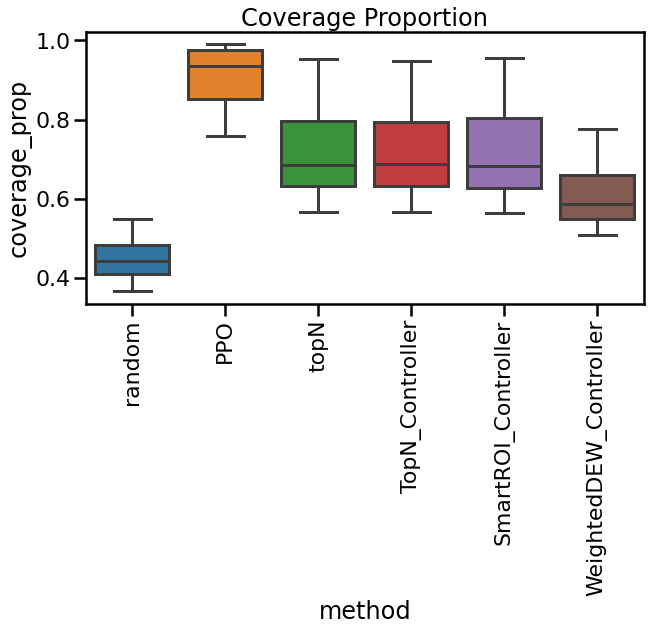

In [30]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='coverage_prop')
plt.xticks(rotation=90)
plt.title('Coverage Proportion')

Text(0.5, 1.0, 'Intensity Proportion')

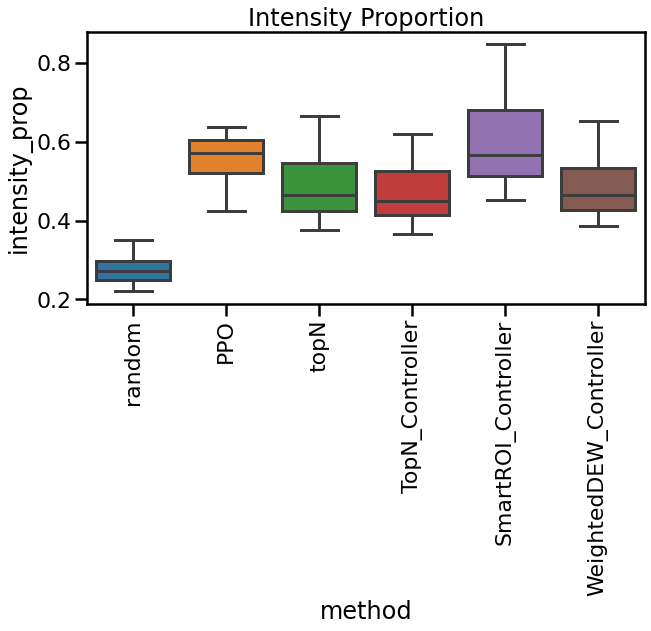

In [31]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='intensity_prop')
plt.xticks(rotation=90)
plt.title('Intensity Proportion')

Text(0.5, 1.0, 'MS1/MS2 Ratio')

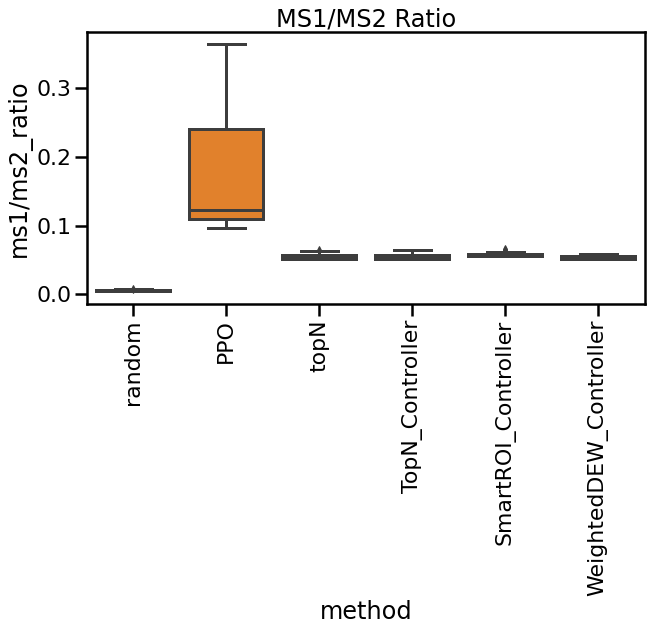

In [32]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='ms1/ms2_ratio')
plt.xticks(rotation=90)
plt.title('MS1/MS2 Ratio')

Text(0.5, 1.0, 'Efficiency')

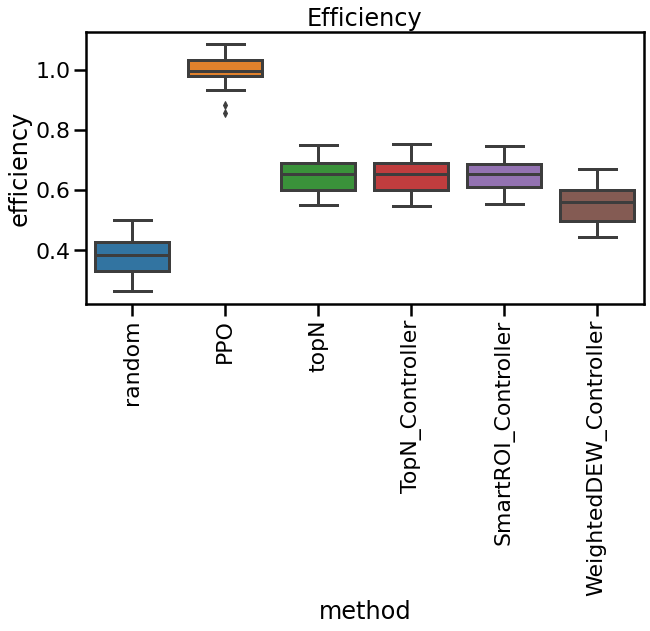

In [33]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='efficiency')
plt.xticks(rotation=90)
plt.title('Efficiency')

Text(0.5, 1.0, 'Precision')

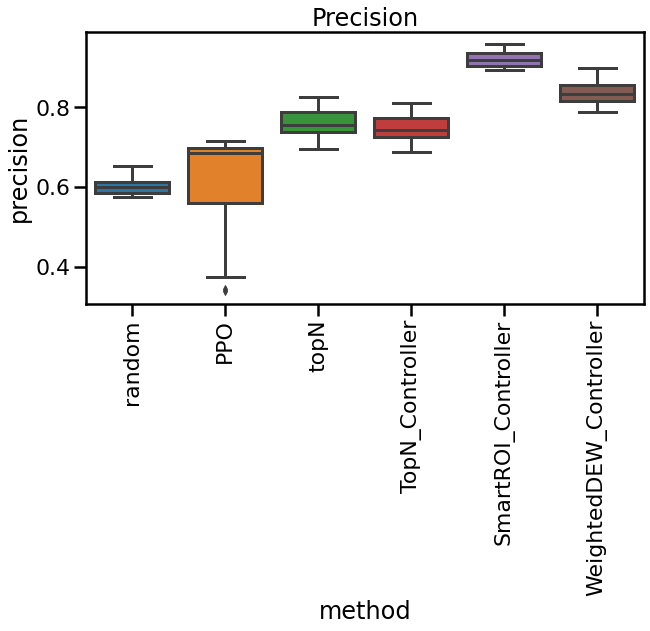

In [34]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='precision')
plt.xticks(rotation=90)
plt.title('Precision')

Text(0.5, 1.0, 'Recall')

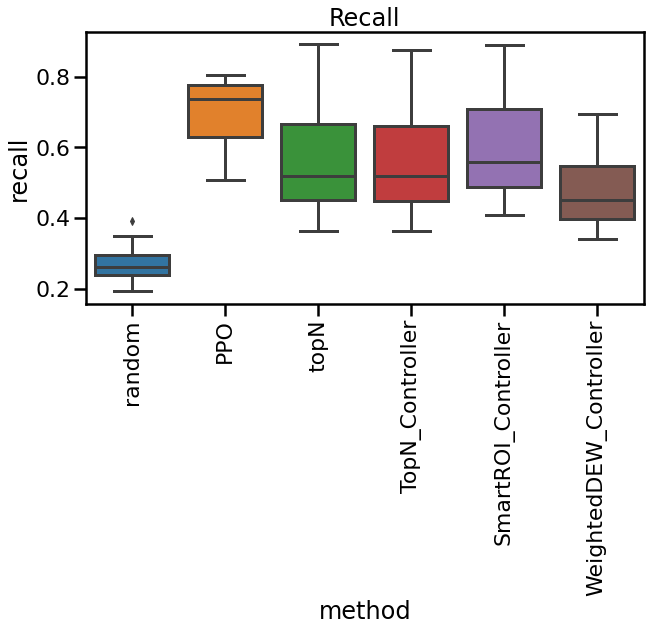

In [35]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='recall')
plt.xticks(rotation=90)
plt.title('Recall')

Text(0.5, 1.0, 'F1')

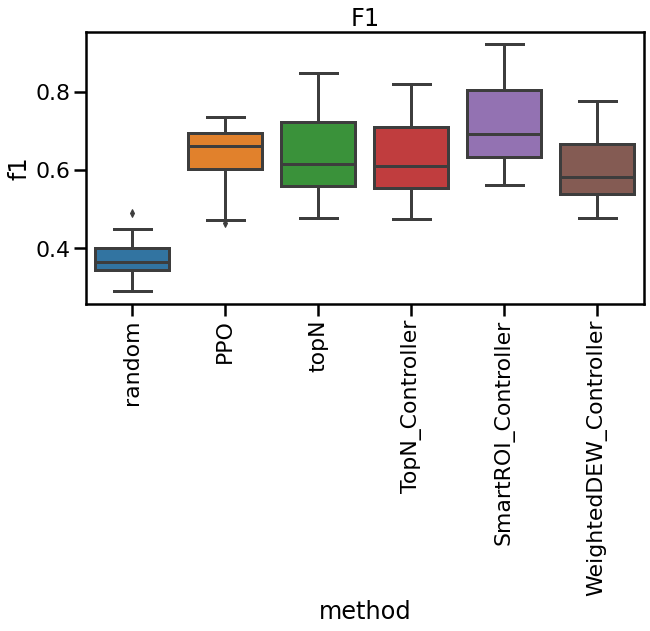

In [36]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='f1')
plt.xticks(rotation=90)
plt.title('F1')

In [38]:
df.to_pickle('evaluation.p')